# SHAP and gain analysis

This notebook evaluates the fixed 12-feature FS1 XGBoost model by
repeated stratified five-fold cross-validation with ten repeats on
`FullDataset.csv`. XGBoost gain is calculated for every fitted fold
model, while SHAP values are calculated for held-out observations.

Four 800 dpi figures are written to
`SHAP_and_Gain_Analysis_outputs`: the repeat-averaged confusion
matrix, mean gain, mean absolute SHAP importance, and the pooled
out-of-fold SHAP beeswarm plot.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    matthews_corrcoef,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)

DATA_FILE = Path("FullDataset.csv")
OUTPUT_DIRECTORY = Path("SHAP_and_Gain_Analysis_outputs")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "Cyclical"
CLASS_NAMES = {0: "Linear", 1: "Cyclic"}
N_SPLITS = 5
N_REPEATS = 10
RANDOM_SEED = 42
THRESHOLD = 0.5
DPI = 800

FEATURES = [
    "Alanine - A",
    "Methionine - M",
    "Tryptophan - W",
    "Isoleucine - I",
    "Cysteine - C",
    "Histidine - H",
    "Asparagine - N",
    "Positive charge",
    "Negative charge",
    "Polar",
    "Non-polar",
    "Amino Acid based volume Score",
]

DISPLAY_NAMES = {
    "Alanine - A": "A",
    "Methionine - M": "M",
    "Tryptophan - W": "W",
    "Isoleucine - I": "I",
    "Cysteine - C": "C",
    "Histidine - H": "H",
    "Asparagine - N": "N",
    "Amino Acid based volume Score": "AA-based vol.",
}

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.dpi": DPI,
})


c:\Users\catha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the modelling dataset


In [2]:
dataset = pd.read_csv(DATA_FILE)

required_columns = [TARGET_COLUMN, *FEATURES]
missing_columns = [
    column for column in required_columns if column not in dataset.columns
]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

X = dataset[FEATURES].copy().reset_index(drop=True)
y = dataset[TARGET_COLUMN].astype(int).reset_index(drop=True)

if set(y.unique()) != {0, 1}:
    raise ValueError("The target column must contain the labels 0 and 1.")
if y.value_counts().min() < N_SPLITS:
    raise ValueError("Each class must contain at least five observations.")

print(f"Observations: {len(dataset)}")
print("Class counts:")
print(y.value_counts().sort_index().rename(index=CLASS_NAMES).to_string())


Observations: 87
Class counts:
Cyclical
Linear    59
Cyclic    28


## Model and analysis functions


In [3]:
def make_model():
    return XGBClassifier(
        eval_metric="logloss",
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0,
        random_state=RANDOM_SEED,
        use_label_encoder=False,
        tree_method="hist",
        device="cpu",
        learning_rate=0.1,
    )


def inverse_frequency_weights(labels):
    prevalence = labels.value_counts(normalize=True).to_dict()
    return labels.map(
        {label: 1.0 / value for label, value in prevalence.items()}
    ).to_numpy()


def positive_class_shap_values(model, features):
    explainer = shap.TreeExplainer(model)
    try:
        values = explainer(features).values
    except Exception as explanation_error:
        try:
            values = explainer.shap_values(features)
        except Exception:
            raise explanation_error

    if isinstance(values, list):
        values = values[0] if len(values) == 1 else values[1]

    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, 1] if values.shape[-1] == 2 else values[1]
    if values.shape != features.shape:
        raise ValueError(
            f"SHAP values have shape {values.shape}; expected {features.shape}."
        )
    return values


def feature_gain(model, feature_names):
    gain = model.get_booster().get_score(importance_type="gain")
    if gain and all(key.startswith("f") and key[1:].isdigit() for key in gain):
        index_to_name = {
            f"f{index}": name for index, name in enumerate(feature_names)
        }
        gain = {
            index_to_name[key]: value
            for key, value in gain.items()
            if key in index_to_name
        }
    return pd.DataFrame({
        "Feature": list(feature_names),
        "Gain": [float(gain.get(name, 0.0)) for name in feature_names],
    })


def nonnegative_sd_errors(means, standard_deviations):
    means = np.asarray(means, dtype=float)
    standard_deviations = np.nan_to_num(
        np.asarray(standard_deviations, dtype=float), nan=0.0
    )
    return np.vstack([
        np.minimum(standard_deviations, np.maximum(means, 0.0)),
        standard_deviations,
    ])


def bold_figure_text(figure):
    for axis in figure.axes:
        axis.xaxis.label.set_fontweight("bold")
        axis.yaxis.label.set_fontweight("bold")
        for text in [
            *axis.get_xticklabels(),
            *axis.get_yticklabels(),
            *axis.texts,
        ]:
            text.set_fontweight("bold")
        legend = axis.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_fontweight("bold")


## Repeated stratified cross-validation


In [4]:
splitter = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED,
)

predictions = []
gain_results = []
shap_values = []
shap_features = []
shap_importance = []

for run, (train_index, held_out_index) in enumerate(
    splitter.split(X, y), start=1
):
    repeat = ((run - 1) // N_SPLITS) + 1
    fold = ((run - 1) % N_SPLITS) + 1
    X_train = X.iloc[train_index]
    X_held_out = X.iloc[held_out_index]
    y_train = y.iloc[train_index]
    y_held_out = y.iloc[held_out_index]

    model = make_model()
    model.fit(
        X_train,
        y_train,
        sample_weight=inverse_frequency_weights(y_train),
        verbose=False,
    )

    probabilities = model.predict_proba(X_held_out)[:, 1]
    predicted = (probabilities >= THRESHOLD).astype(int)
    predictions.append(pd.DataFrame({
        "Repeat": repeat,
        "Fold": fold,
        "True": y_held_out.to_numpy(),
        "Predicted": predicted,
    }))

    fold_gain = feature_gain(model, X.columns)
    fold_gain["Run"] = run
    gain_results.append(fold_gain)

    fold_shap = positive_class_shap_values(model, X_held_out)
    shap_values.append(fold_shap)
    shap_features.append(X_held_out.reset_index(drop=True))
    shap_importance.append(pd.DataFrame({
        "Run": run,
        "Feature": X.columns,
        "MeanAbsoluteSHAP": np.abs(fold_shap).mean(axis=0),
    }))

predictions = pd.concat(predictions, ignore_index=True)
gain_results = pd.concat(gain_results, ignore_index=True)
shap_values = np.vstack(shap_values)
shap_features = pd.concat(shap_features, ignore_index=True)
shap_importance = pd.concat(shap_importance, ignore_index=True)

repeat_metrics = []
repeat_percentages = []
for repeat, repeat_predictions in predictions.groupby("Repeat", sort=True):
    true = repeat_predictions["True"].to_numpy()
    predicted = repeat_predictions["Predicted"].to_numpy()
    matrix = confusion_matrix(true, predicted, labels=[0, 1])
    repeat_percentages.append(
        matrix / matrix.sum(axis=1, keepdims=True) * 100
    )
    repeat_metrics.append({
        "Accuracy": accuracy_score(true, predicted),
        "Balanced accuracy": balanced_accuracy_score(true, predicted),
        "MCC": matthews_corrcoef(true, predicted),
    })

repeat_metrics = pd.DataFrame(repeat_metrics)
repeat_percentages = np.stack(repeat_percentages)
mean_percentages = repeat_percentages.mean(axis=0)
sd_percentages = repeat_percentages.std(axis=0, ddof=1)

gain_summary = (
    gain_results.groupby("Feature", as_index=False)
    .agg(Mean=("Gain", "mean"), SD=("Gain", "std"))
    .sort_values("Mean", ascending=False, ignore_index=True)
)
shap_summary = (
    shap_importance.groupby("Feature", as_index=False)
    .agg(
        Mean=("MeanAbsoluteSHAP", "mean"),
        SD=("MeanAbsoluteSHAP", "std"),
    )
    .sort_values("Mean", ascending=False, ignore_index=True)
)

print("Metrics across the ten complete repeats:")
for metric in repeat_metrics.columns:
    print(
        f"{metric}: {repeat_metrics[metric].mean():.3f} +/- "
        f"{repeat_metrics[metric].std(ddof=1):.3f}"
    )


Metrics across the ten complete repeats:
Accuracy: 0.900 +/- 0.024
Balanced accuracy: 0.892 +/- 0.029
MCC: 0.775 +/- 0.054


## Figures


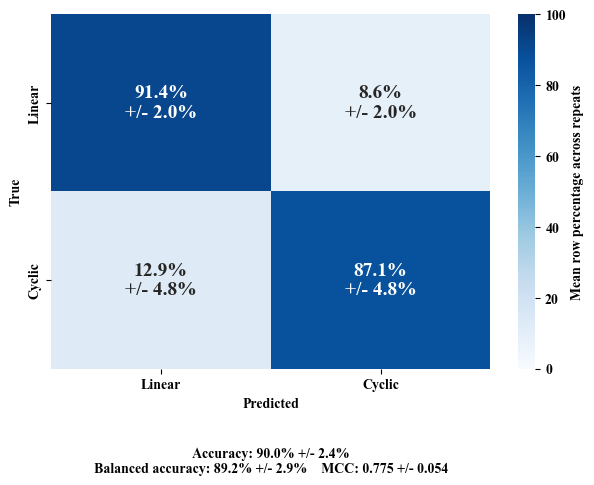

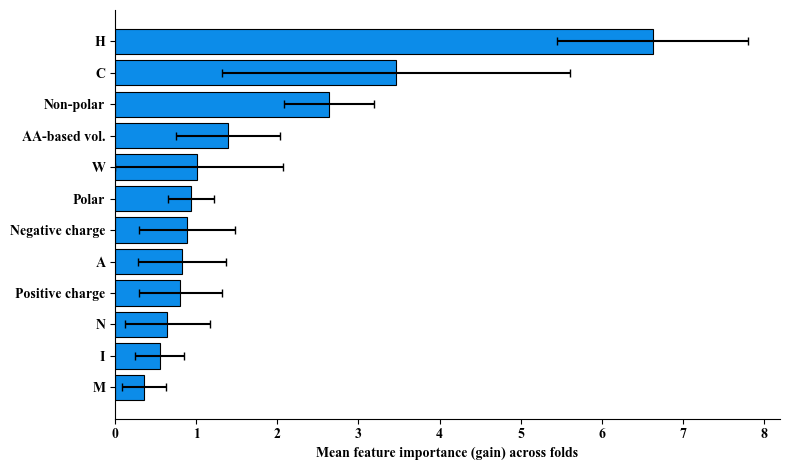

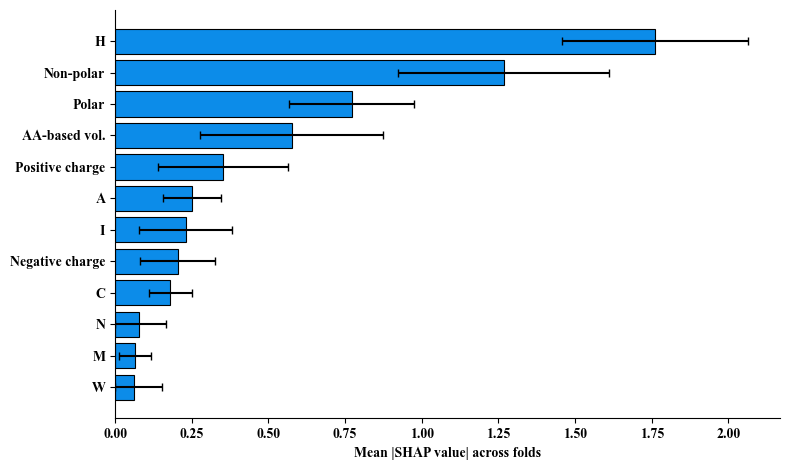

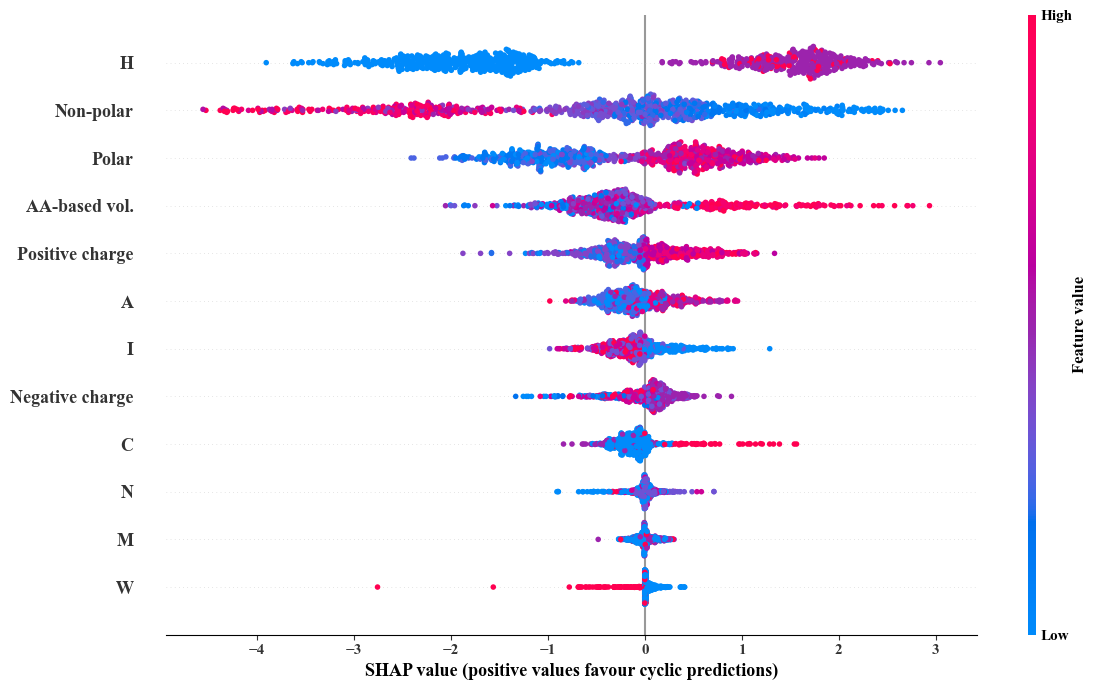

In [5]:
annotations = np.empty((2, 2), dtype=object)
for row in range(2):
    for column in range(2):
        annotations[row, column] = (
            f"{mean_percentages[row, column]:.1f}%"
            f"\n+/- {sd_percentages[row, column]:.1f}%"
        )

metrics_text = (
    f"Accuracy: {100 * repeat_metrics['Accuracy'].mean():.1f}% +/- "
    f"{100 * repeat_metrics['Accuracy'].std(ddof=1):.1f}%\n"
    f"Balanced accuracy: "
    f"{100 * repeat_metrics['Balanced accuracy'].mean():.1f}% +/- "
    f"{100 * repeat_metrics['Balanced accuracy'].std(ddof=1):.1f}%"
    f"    MCC: {repeat_metrics['MCC'].mean():.3f} +/- "
    f"{repeat_metrics['MCC'].std(ddof=1):.3f}"
)

figure, axis = plt.subplots(figsize=(6.2, 5.8))
sns.heatmap(
    mean_percentages,
    annot=annotations,
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Mean row percentage across repeats"},
    xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
    ax=axis,
)
axis.set_xlabel("Predicted")
axis.set_ylabel("True")
axis.text(
    0.5,
    -0.22,
    metrics_text,
    transform=axis.transAxes,
    ha="center",
    va="top",
    fontweight="bold",
)
bold_figure_text(figure)
figure.tight_layout(rect=[0, 0.11, 1, 1])
figure.savefig(
    OUTPUT_DIRECTORY / "RepeatedCV_ConfusionMatrix.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()
plt.close(figure)

gain_labels = gain_summary["Feature"].map(DISPLAY_NAMES).fillna(
    gain_summary["Feature"]
)
figure, axis = plt.subplots(
    figsize=(8, max(4, 0.4 * len(gain_summary)))
)
axis.barh(
    gain_labels,
    gain_summary["Mean"],
    xerr=nonnegative_sd_errors(gain_summary["Mean"], gain_summary["SD"]),
    capsize=3,
    edgecolor="black",
    linewidth=0.8,
    color="#0C8CE9",
)
axis.invert_yaxis()
axis.set_xlim(left=0)
axis.set_xlabel("Mean feature importance (gain) across folds")
bold_figure_text(figure)
figure.tight_layout()
figure.savefig(
    OUTPUT_DIRECTORY / "RepeatedCV_MeanGain.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.1,
)
plt.show()
plt.close(figure)

shap_labels = shap_summary["Feature"].map(DISPLAY_NAMES).fillna(
    shap_summary["Feature"]
)
figure, axis = plt.subplots(
    figsize=(8, max(4, 0.4 * len(shap_summary)))
)
axis.barh(
    shap_labels,
    shap_summary["Mean"],
    xerr=nonnegative_sd_errors(shap_summary["Mean"], shap_summary["SD"]),
    capsize=3,
    edgecolor="black",
    linewidth=0.8,
    color="#0C8CE9",
)
axis.invert_yaxis()
axis.set_xlim(left=0)
axis.set_xlabel("Mean |SHAP value| across folds")
bold_figure_text(figure)
figure.tight_layout()
figure.savefig(
    OUTPUT_DIRECTORY / "RepeatedCV_SHAP_Bar.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.2,
)
plt.show()
plt.close(figure)

displayed_features = shap_features.rename(columns=DISPLAY_NAMES)
shap.summary_plot(
    shap_values,
    displayed_features,
    plot_type="dot",
    max_display=len(FEATURES),
    plot_size=(12, 7),
    show=False,
)
figure = plt.gcf()
figure.axes[0].set_xlabel(
    "SHAP value (positive values favour cyclic predictions)"
)
bold_figure_text(figure)
figure.tight_layout()
figure.savefig(
    OUTPUT_DIRECTORY / "RepeatedCV_SHAP_Beeswarm.png",
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.2,
)
plt.show()
plt.close(figure)
